In [1]:
import json

# Путь к COCO-аннотациям
with open('openimages_exported_coco_large/labels.json', 'r') as f:
    data = json.load(f)

annotations = data['annotations']
image_info = {img['id']: (img['width'], img['height']) for img in data['images']}

# Подсчёт small/medium/large
small, medium, large = 0, 0, 0

for ann in annotations:
    area = ann['area']
    
    if area < 32**2:
        small += 1
    elif area < 96**2:
        medium += 1
    else:
        large += 1

total = small + medium + large

print(f"Total annotations: {total}")
print(f"Small objects: {small} ({100 * small / total:.2f}%)")
print(f"Medium objects: {medium} ({100 * medium / total:.2f}%)")
print(f"Large objects: {large} ({100 * large / total:.2f}%)")

print(0.188 * small)
print(0.1 * small)

Total annotations: 11102
Small objects: 842 (7.58%)
Medium objects: 2284 (20.57%)
Large objects: 7976 (71.84%)
158.296
84.2


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import json
import pandas as pd



In [3]:
def read_logs(path):
    if isinstance(path, str):
        path = [path]
    
    train = pd.DataFrame()
    test = pd.DataFrame()

    for p in path:
        with open(p, 'r') as f:
            base_line_data = f.readlines()
            print(f'Base line data length: {len(base_line_data)}')
            skipped = 0
            for i, line in enumerate(base_line_data[1:], start=2):
                try:
                    line = json.loads(line)
                    if 'mode' not in line or line['epoch'] > 6:
                        skipped += 1
                        continue

                    if line['mode'] == 'train':
                        if train.columns.empty:
                            train = pd.DataFrame(columns=line.keys())
                        train.loc[len(train)] = line
                    elif line['mode'] == 'val':
                        if test.columns.empty:
                            test = pd.DataFrame(columns=line.keys())
                        test.loc[len(test)] = line
                except json.JSONDecodeError:
                    print(f"Skipped malformed JSON at line {i}: {line[:80]}...")
                    skipped += 1

            print(f"Train rows: {len(train)}, Val rows: {len(test)}, Skipped: {skipped}")

    return train, test


In [4]:
improved_mim_path = ['work_dirs/mim_with_swin_improved_mim_weight05/20250522_164839.log.json', 'work_dirs/mim_with_swin_improved_mim_weight05/20250522_211420.log.json']
# improved_mim__head_filtered_path = ['work_dirs/mim_with_swin_improved_head_filtered/20250521_205222.log.json'] # sota
mim_with_more_masking_path = 'work_dirs/mim_with_swin_improved_mim_masking/20250523_170351.log.json'
baseline_path = 'work_dirs/swin_baseline/20250520_213134.log.json'
baseline_masked = 'work_dirs/swin_baseline_masked/20250522_201139.log.json'

In [5]:
improved_mim_train, improved_mim_test, improved_mim_label = *read_logs(improved_mim_path), 'Co-detr + MIM весом 0.5'
# improved_mim__head_filtered_train, improved_mim__head_filtered_test = read_logs(improved_mim__head_filtered_path)
mim_with_more_masking_train, mim_with_more_masking_test, mim_with_more_masking_label = *read_logs(mim_with_more_masking_path), 'Co-detr + MIM весом 1'
baseline_train, baseline_test, baseline_label = *read_logs(baseline_path), 'Co-detr'
baseline_masking_train, baseline_masking_test, baseline_masking_label = *read_logs(baseline_masked), 'Co-detr с маскированием'

Base line data length: 430
Train rows: 428, Val rows: 1, Skipped: 0
Base line data length: 1981
Train rows: 2398, Val rows: 6, Skipped: 5
Base line data length: 3553
Train rows: 3546, Val rows: 6, Skipped: 0
Base line data length: 1607
Train rows: 1182, Val rows: 6, Skipped: 418
Base line data length: 1388
Train rows: 1182, Val rows: 6, Skipped: 199


In [6]:
improved_mim_train

,mode,epoch,iter,lr,memory,data_time,enc_loss_cls,enc_loss_bbox,enc_loss_iou,loss_cls,...,loss_iou_aux1,d0.loss_cls_aux1,d0.loss_bbox_aux1,d0.loss_iou_aux1,d1.loss_cls_aux1,d1.loss_bbox_aux1,d1.loss_iou_aux1,loss,grad_norm,time
0,train,1,50,0.00002,6857,0.06328,1.58247,1.09597,1.20880,1.79582,...,1.21085,1.47739,1.26079,1.21135,1.50688,1.26026,1.21091,65.09925,63.44503,0.78573
1,train,1,100,0.00002,6877,0.01615,1.38950,0.92298,1.17270,1.55072,...,1.21543,1.20691,1.18485,1.21555,1.21886,1.18368,1.21554,60.38972,45.89209,0.53436
2,train,1,150,0.00002,6901,0.01628,1.33842,0.95954,1.16841,1.50816,...,1.22548,1.11444,1.17821,1.22557,1.13873,1.17736,1.22590,59.28704,44.11919,0.63256
3,train,1,200,0.00002,6901,0.01759,1.31449,0.86013,1.19347,1.42431,...,1.25356,1.00515,1.15043,1.25471,1.02883,1.14965,1.25446,58.46420,47.12821,0.60613
4,train,1,250,0.00002,6937,0.01517,1.30741,0.91081,1.12170,1.48753,...,1.20303,1.01373,1.20684,1.20649,1.02908,1.20548,1.20557,58.16068,48.41423,0.57137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2393,train,6,19500,0.00002,7021,0.02012,0.71865,0.26626,0.60759,0.68581,...,0.43569,0.31627,0.33258,0.50471,0.27337,0.27913,0.43955,25.80026,55.21366,0.59234
2394,train,6,19550,0.00002,7021,0.01948,0.74352,0.27632,0.58333,0.68518,...,0.42335,0.31382,0.32930,0.49459,0.26682,0.27173,0.42698,25.53753,52.98428,0.58128
2395,train,6,19600,0.00002,7021,0.02913,0.73902,0.28633,0.58769,0.67118,...,0.42447,0.29427,0.34078,0.49740,0.25352,0.28424,0.42842,25.18310,53.95515,0.59341
2396,train,6,19650,0.00002,7021,0.02036,0.72431,0.27059,0.58004,0.68479,...,0.42999,0.31133,0.33102,0.50438,0.27490,0.27480,0.43300,25.46040,54.90041,0.59440


## График метрик

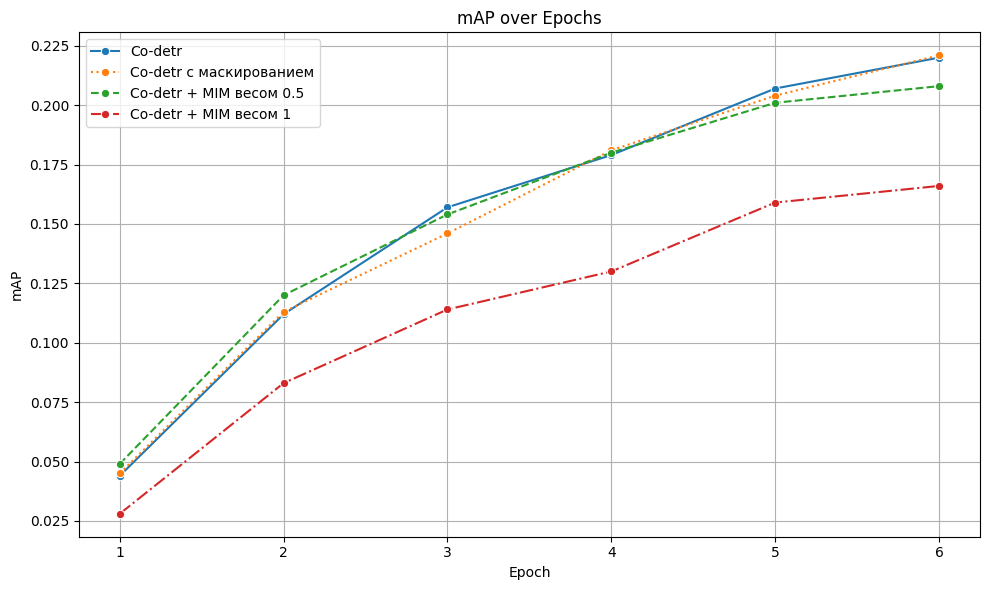

In [7]:
import seaborn as sns


x = 'epoch'
y = 'bbox_mAP'
def plot_val_data(x, y, xlabel='epoch', ylabel='mAP', title='mAP over Epochs', return_fig=False):
    plt.figure(figsize=(10, 6))

    sns.lineplot(data=baseline_test, x=x, y=y, label=baseline_label, marker='o')
    sns.lineplot(data=baseline_masking_test, x=x, y=y, label=baseline_masking_label, marker='o', linestyle=':')
    sns.lineplot(data=improved_mim_test, x=x, y=y, label=improved_mim_label, marker='o', linestyle='--')
    sns.lineplot(data=mim_with_more_masking_test, x=x, y=y, label=mim_with_more_masking_label, marker='o', linestyle='-.')

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(np.arange(improved_mim_test['epoch'].min(), improved_mim_test['epoch'].max() + 1, 1))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    if return_fig:
        return plt.gcf()
    else:
        plt.show()

test = plot_val_data(x, y, xlabel='Epoch', ylabel='mAP', title='mAP over Epochs', return_fig=True)

In [8]:
test.show()

/tmp/ipykernel_63581/2036373597.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  test.show()


In [9]:
improved_mim_test.head()

,mode,epoch,iter,lr,bbox_mAP,bbox_mAP_50,bbox_mAP_75,bbox_mAP_s,bbox_mAP_m,bbox_mAP_l,bbox_mAP_copypaste
0,val,1,5000,0.00002,0.049,0.084,0.048,0.026,0.054,0.077,0.049 0.084 0.048 0.026 0.054 0.077
1,val,2,5000,0.00002,0.120,0.194,0.124,0.051,0.124,0.188,0.120 0.194 0.124 0.051 0.124 0.188
2,val,3,5000,0.00002,0.154,0.239,0.161,0.060,0.167,0.237,0.154 0.239 0.161 0.060 0.167 0.237
3,val,4,5000,0.00002,0.180,0.282,0.189,0.068,0.191,0.285,0.180 0.282 0.189 0.068 0.191 0.285
4,val,5,5000,0.00002,0.201,0.310,0.213,0.081,0.217,0.309,0.201 0.310 0.213 0.081 0.217 0.309


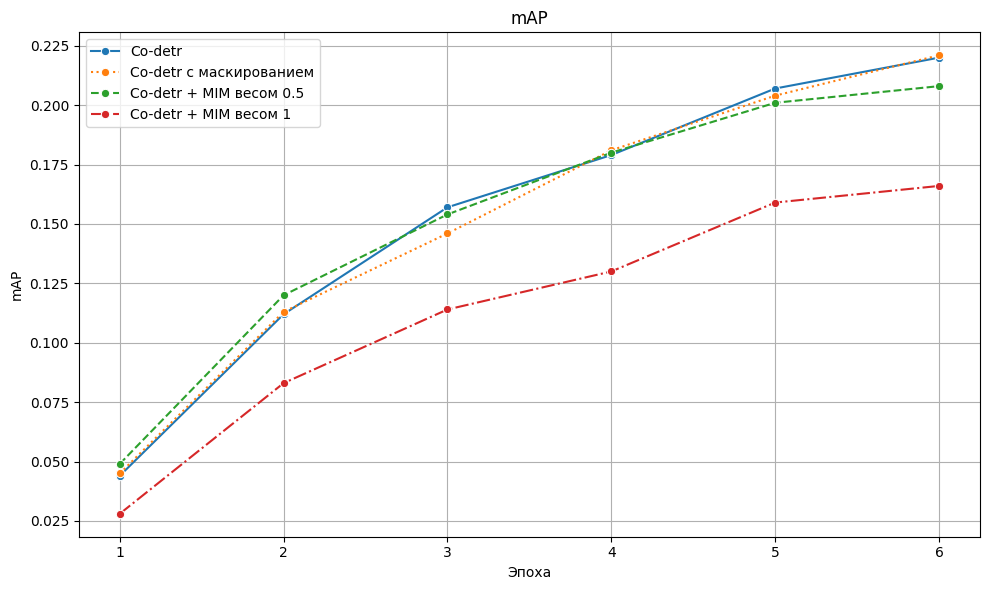

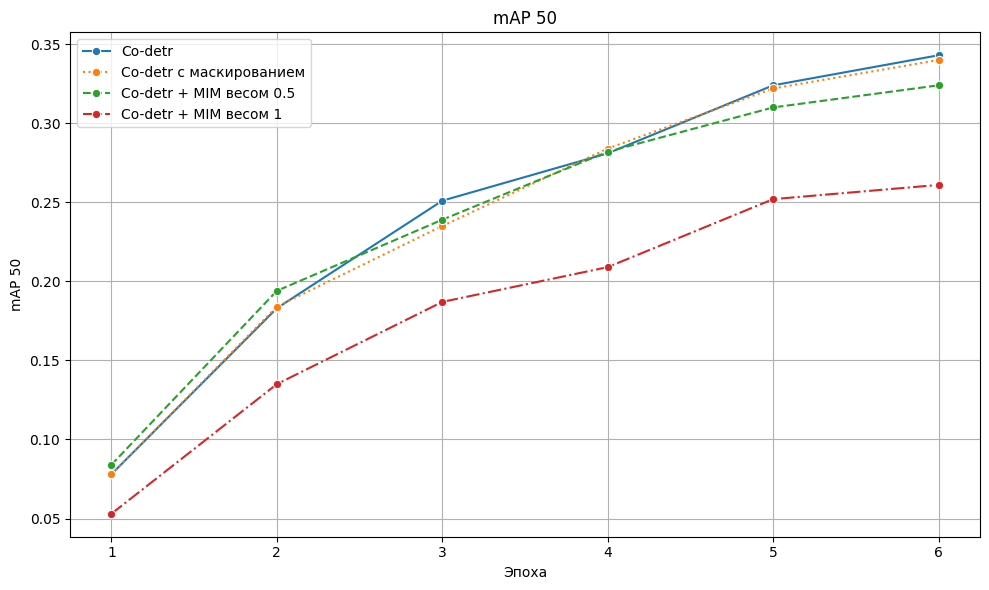

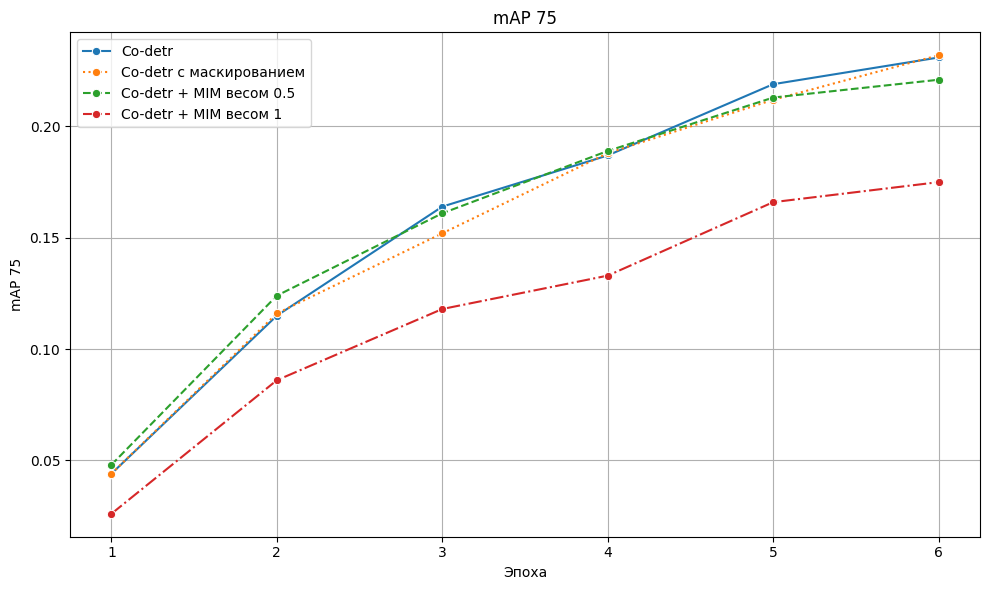

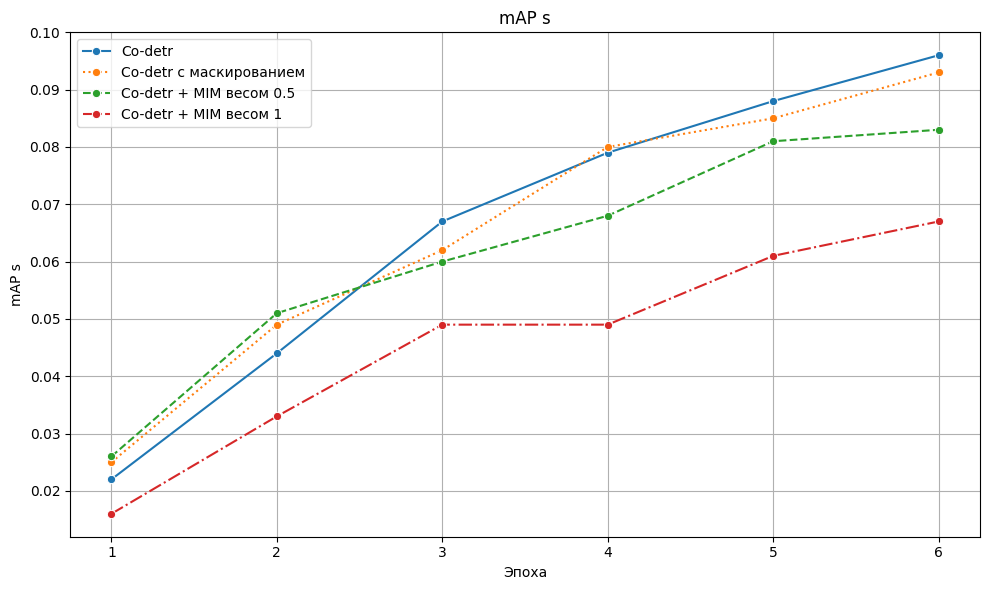

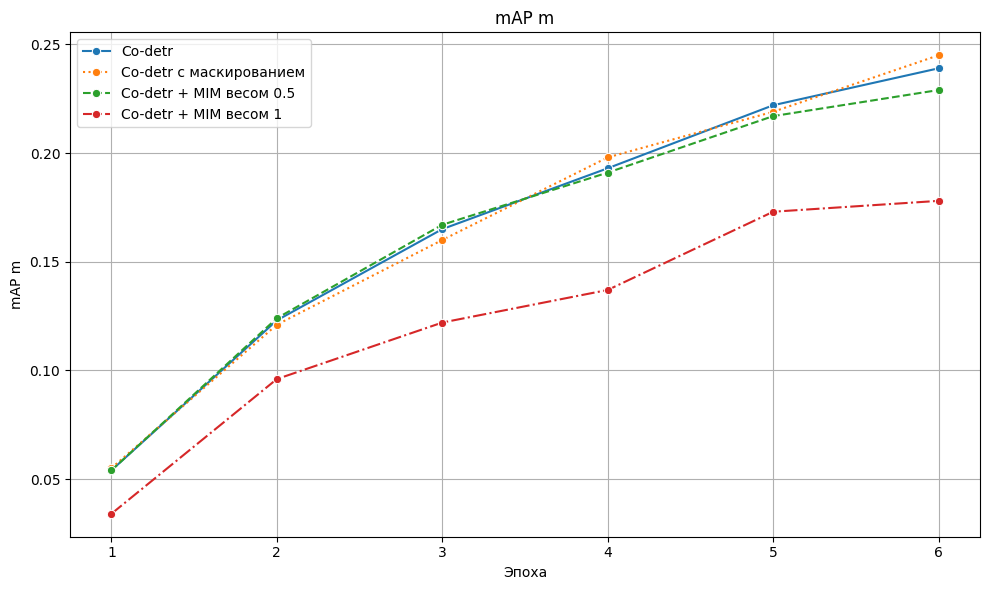

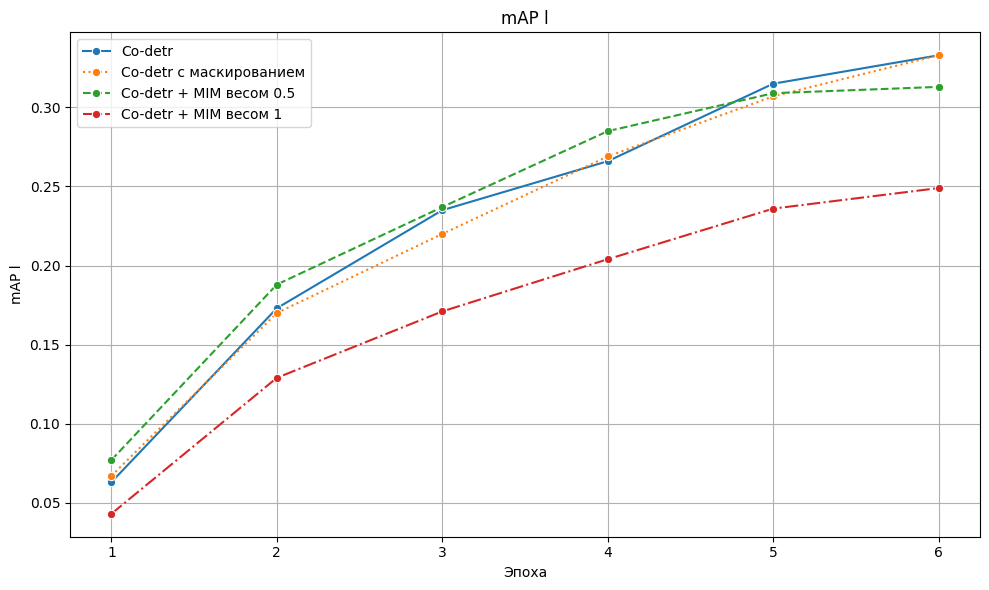

In [10]:
for i in improved_mim_test.columns[:-1]:
    if 'bbox' in i:
        plot_val_data('epoch', i, xlabel='Эпоха', ylabel=' '.join(i.split('_')[1:]), title=' '.join(i.split('_')[1:]))


In [11]:
improved_mim_train.head()

,mode,epoch,iter,lr,memory,data_time,enc_loss_cls,enc_loss_bbox,enc_loss_iou,loss_cls,...,loss_iou_aux1,d0.loss_cls_aux1,d0.loss_bbox_aux1,d0.loss_iou_aux1,d1.loss_cls_aux1,d1.loss_bbox_aux1,d1.loss_iou_aux1,loss,grad_norm,time
0,train,1,50,0.00002,6857,0.06328,1.58247,1.09597,1.20880,1.79582,...,1.21085,1.47739,1.26079,1.21135,1.50688,1.26026,1.21091,65.09925,63.44503,0.78573
1,train,1,100,0.00002,6877,0.01615,1.38950,0.92298,1.17270,1.55072,...,1.21543,1.20691,1.18485,1.21555,1.21886,1.18368,1.21554,60.38972,45.89209,0.53436
2,train,1,150,0.00002,6901,0.01628,1.33842,0.95954,1.16841,1.50816,...,1.22548,1.11444,1.17821,1.22557,1.13873,1.17736,1.22590,59.28704,44.11919,0.63256
3,train,1,200,0.00002,6901,0.01759,1.31449,0.86013,1.19347,1.42431,...,1.25356,1.00515,1.15043,1.25471,1.02883,1.14965,1.25446,58.46420,47.12821,0.60613
4,train,1,250,0.00002,6937,0.01517,1.30741,0.91081,1.12170,1.48753,...,1.20303,1.01373,1.20684,1.20649,1.02908,1.20548,1.20557,58.16068,48.41423,0.57137


In [12]:
improved_mim_train['loss_od'] = improved_mim_train['loss'] - improved_mim_train['loss_mim']
mim_with_more_masking_train['loss_od'] = mim_with_more_masking_train['loss'] - mim_with_more_masking_train['loss_mim']

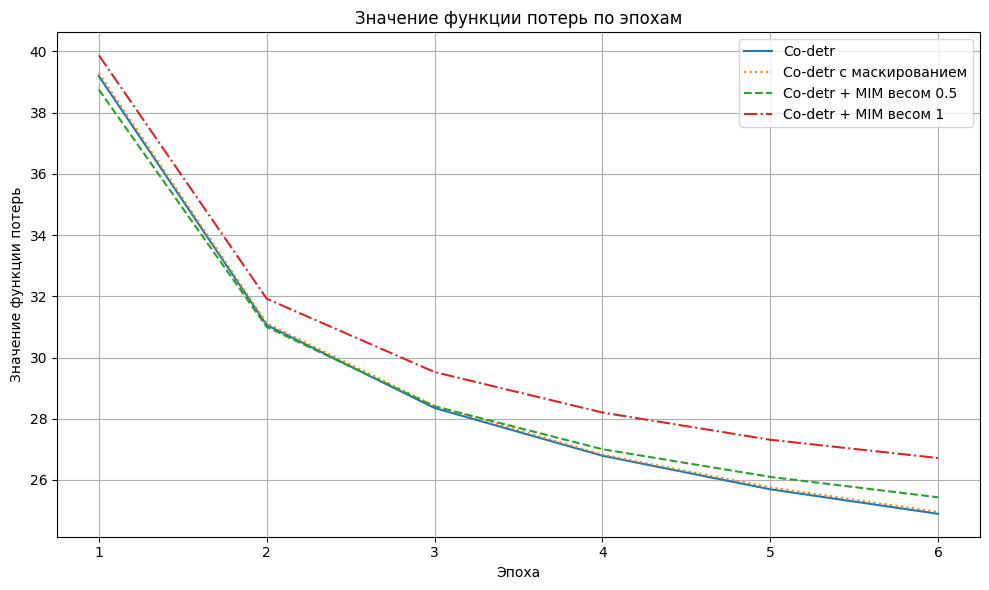

In [13]:
plt.figure(figsize=(10, 6))

sns.lineplot(data=baseline_train, x='epoch', y='loss', label=baseline_label, errorbar=None)
sns.lineplot(data=baseline_masking_train, x='epoch', y='loss', label=baseline_masking_label, linestyle=':', errorbar=None)
sns.lineplot(data=improved_mim_train, x='epoch', y='loss_od', label=improved_mim_label, linestyle='--', errorbar=None)
sns.lineplot(data=mim_with_more_masking_train, x='epoch', y='loss_od', label=mim_with_more_masking_label, linestyle='-.', errorbar=None)


plt.title('Значение функции потерь по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Значение функции потерь')
plt.xticks(np.arange(improved_mim_test['epoch'].min(), improved_mim_test['epoch'].max() + 1, 1))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.116
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=1000 ] = 0.177
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=1000 ] = 0.120
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=1000 ] = 0.046
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=1000 ] = 0.129
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=1000 ] = 0.179
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.238
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=300 ] = 0.238
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=1000 ] = 0.238
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1000 ] = 0.090
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=1000 ] = 0.253
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=1000 ] = 0.386

In [14]:
from pathlib import Path
import json

mim_base_dir = 'work_dirs/mim_with_swin_improved_mim_weight05'
more_masked_base_dir = 'work_dirs/mim_with_swin_improved_mim_masking'
baseline_base_dir = 'work_dirs/swin_baseline'
baseline_masked_base_dir = 'work_dirs/swin_baseline_masked'

def get_eval_jsons(base_dir):
    """
    Рекурсивно ищет все файлы eval_*.json в папках masking_test/masking_0X
    и возвращает список с кортежами (путь к файлу, содержимое файла).
    """
    base_dir = Path(base_dir)
    results = []
    for json_path in base_dir.rglob('masking_tests/masking_0*/eval_*.json'):
        with open(json_path, 'r') as f:
            try:
                data = json.load(f)
                results.append((json_path, data))  # можно сохранить и путь, и содержимое
            except json.JSONDecodeError:
                print(f"⚠️ Не удалось прочитать: {json_path}")
    if len(results) == 0:
        print(f"⚠️ Не найдено eval_*.json в {base_dir}")
        return pd.DataFrame()
    cols = ['masking_percentage', *results[0][1]['metric'].keys()]
    # print([results[i][1]['config'] for i in range(len(results))], [results[i][1]['config'][results[0][1]['config'].find('.py') - 1] for i in range(len(results))])
    parsed_res = [[int(results[i][1]['config'][results[0][1]['config'].find('.py') - 1]) / 10, *results[i][1]['metric'].values()][:8] for i in  range(len(results))]
    data = pd.DataFrame(parsed_res, columns=cols)

    return data

mim_base_data = get_eval_jsons(mim_base_dir)
more_masked_base_data = get_eval_jsons(more_masked_base_dir)
baseline_base_data = get_eval_jsons(baseline_base_dir)
baseline_masked_base_data = get_eval_jsons(baseline_masked_base_dir)


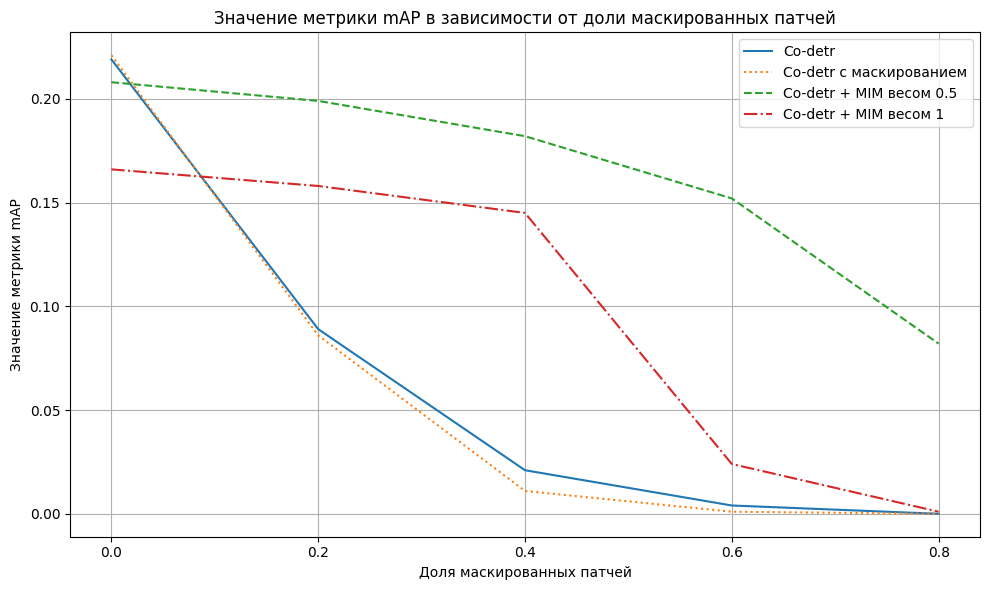

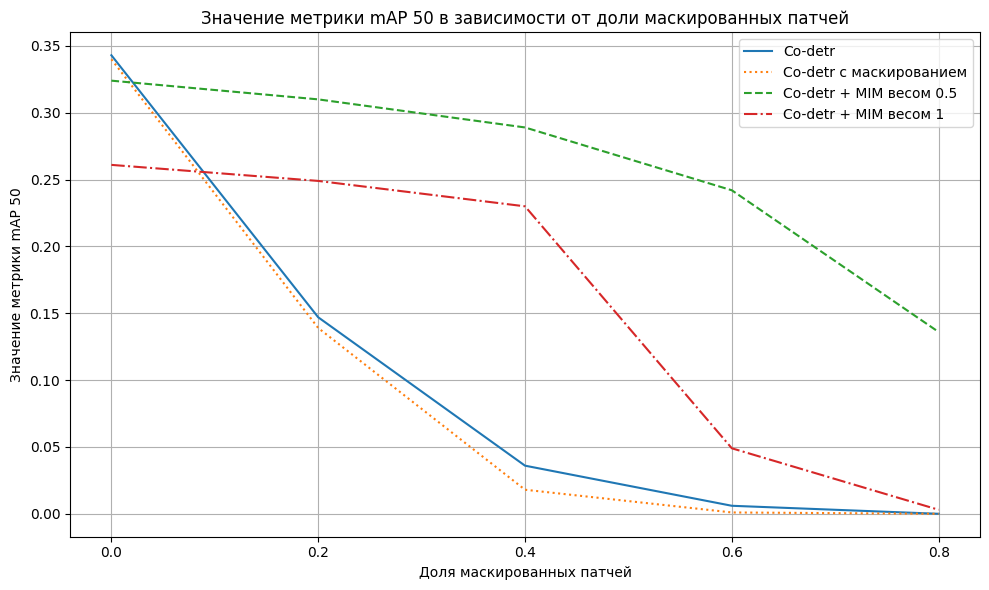

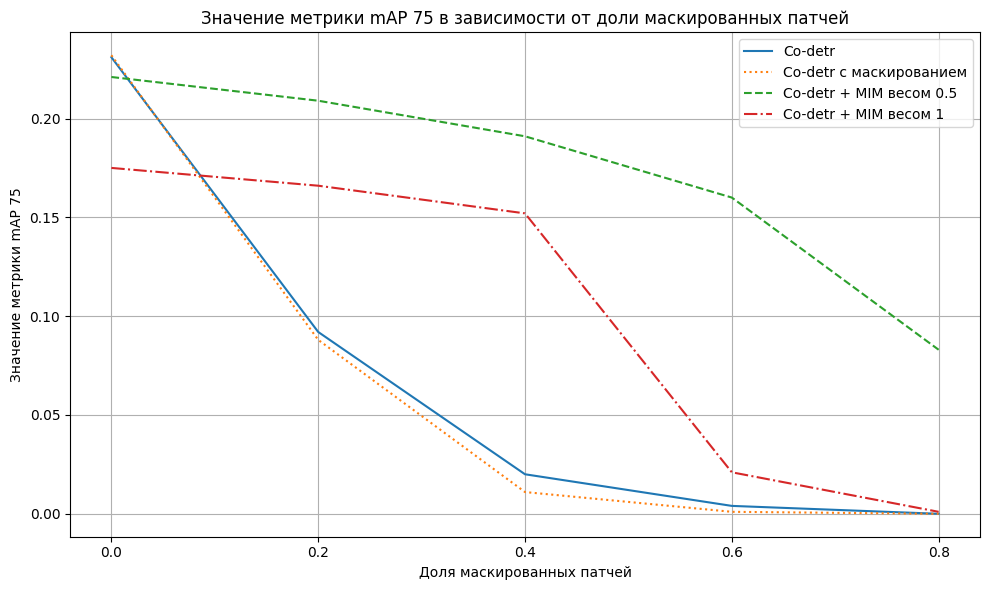

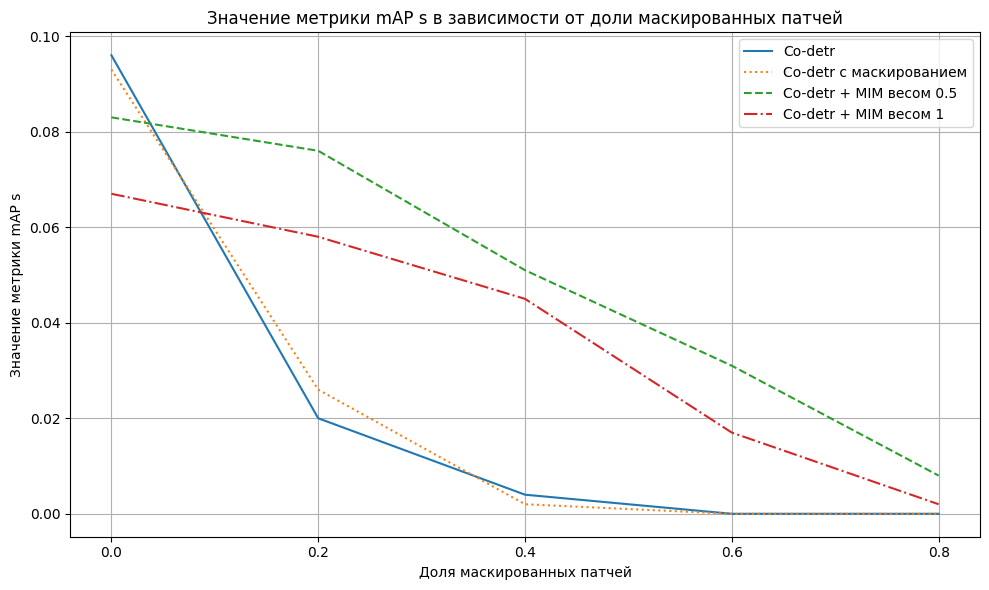

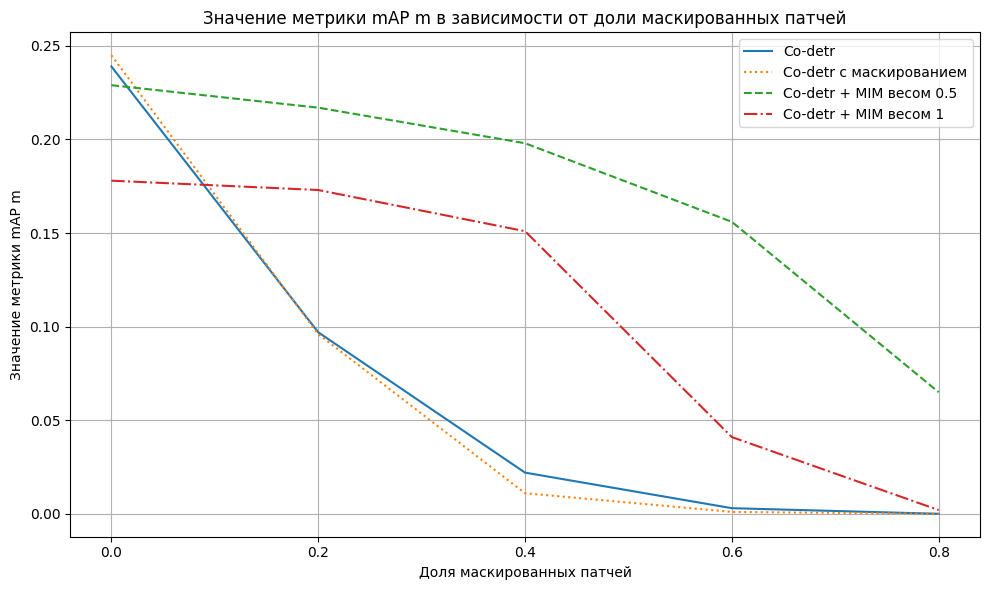

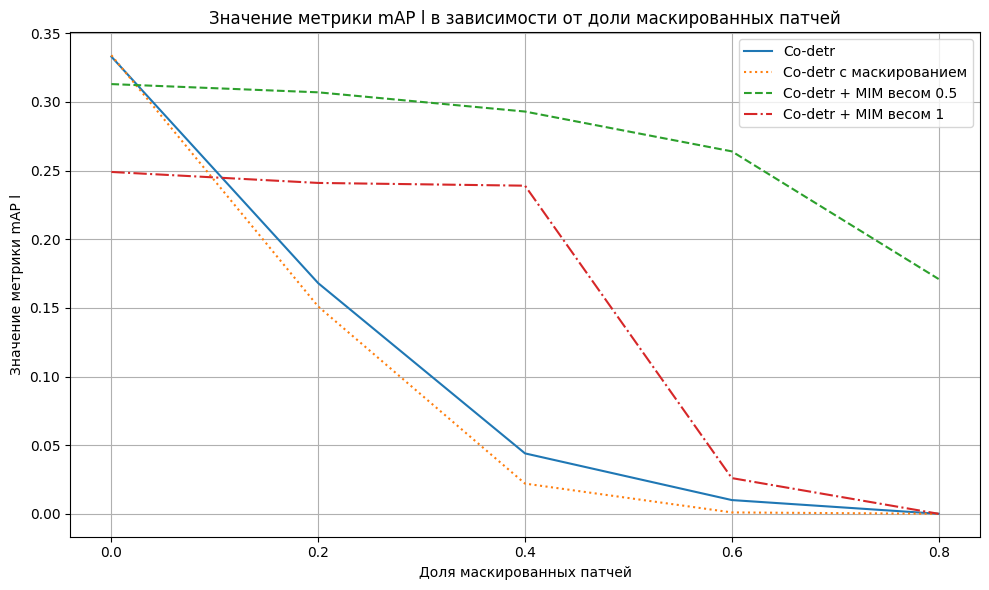

In [15]:
import seaborn as sns

def plot_robsutness(y):
    plt.figure(figsize=(10, 6))

    sns.lineplot(data=baseline_base_data, x='masking_percentage', y=y, label=baseline_label)
    sns.lineplot(data=baseline_masked_base_data, x='masking_percentage', y=y, label=baseline_masking_label, linestyle=':')
    sns.lineplot(data=mim_base_data, x='masking_percentage', y=y, label=improved_mim_label, linestyle='--')
    sns.lineplot(data=more_masked_base_data, x='masking_percentage', y=y, label=mim_with_more_masking_label, linestyle='-.')

    plt.title(f"Значение метрики {' '.join(y.split('_')[1:])} в зависимости от доли маскированных патчей")
    plt.xlabel('Доля маскированных патчей')
    plt.ylabel(f"Значение метрики {' '.join(y.split('_')[1:])}")
    plt.xticks(np.arange(0, 1, step=0.2))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show

for i in improved_mim_test.columns[:-1]:
    if 'bbox' in i:
        plot_robsutness(i)
        # test = plot_val_data(x, y, xlabel='Epoch', ylabel='mAP', title='mAP over Epochs', return_fig=True)

прогнать open images валидацию
если учить с мимом работать должна лучше, чем без на других датасетах

In [62]:
from pathlib import Path
import json

mim_base_dir = 'work_dirs/mim_with_swin_improved_mim_weight05'
# more_masked_base_dir = 'work_dirs/mim_with_swin_improved_mim_masking'
baseline_base_dir = 'work_dirs/swin_baseline'
# baseline_masked_base_dir = 'work_dirs/swin_baseline_masked'

def get_eval_jsons(base_dir):
    """
    Рекурсивно ищет все файлы eval_*.json в папках masking_test/masking_0X
    и возвращает список с кортежами (путь к файлу, содержимое файла).
    """
    base_dir = Path(base_dir)
    results = []
    for json_path in base_dir.rglob('grid/grid*/eval_*.json'):
        with open(json_path, 'r') as f:
            try:
                data = json.load(f)
                results.append((json_path, data))  # можно сохранить и путь, и содержимое
            except json.JSONDecodeError:
                print(f"⚠️ Не удалось прочитать: {json_path}")
    if len(results) == 0:
        print(f"⚠️ Не найдено eval_*.json в {base_dir}")
        return pd.DataFrame()
    print(len(results[0][1]['metric'].keys()))
    cols = ['grid_ratio', 'cut_num', *results[0][1]['metric'].keys()][:-1]
    # print([results[i][1]['config'] for i in range(len(results))], [results[i][1]['config'][results[0][1]['config'].find('.py') - 1] for i in range(len(results))])
    # print(results[0][1]['config'].split('/')[-1].split('.')[0].split('_')[-3::2])
    params = [results[i][1]['config'].split('/')[-1].split('.')[0].split('_')[-3::2] for i in range(len(results))]
    grid_ratios = [ int(i[0]) / 10 for i in params]
    cut = [int(i[1]) for i in params]

    parsed_res = [[grid_ratios[i], cut[i], *results[i][1]['metric'].values()][:-1] for i in  range(len(results))]
    data = pd.DataFrame(parsed_res, columns=cols)

    return data

mim_base_data = get_eval_jsons(mim_base_dir)
# more_masked_base_data = get_eval_jsons(more_masked_base_dir)
baseline_base_data = get_eval_jsons(baseline_base_dir)
# baseline_masked_base_data = get_eval_jsons(baseline_masked_base_dir)


13
13


In [63]:
mim_base_data

,grid_ratio,cut_num,bbox_AR@100,bbox_AR@300,bbox_AR@1000,bbox_AR_s@1000,bbox_AR_m@1000,bbox_AR_l@1000,bbox_mAP,bbox_mAP_50,bbox_mAP_75,bbox_mAP_s,bbox_mAP_m,bbox_mAP_l
0,0.7,16,0.050,0.050,0.050,0.021,0.040,0.062,0.010,0.022,0.007,0.005,0.010,0.014
1,0.7,16,0.009,0.022,0.007,0.005,0.009,0.014,NaN,NaN,NaN,NaN,NaN,NaN
2,0.5,32,0.053,0.103,0.048,0.021,0.047,0.089,NaN,NaN,NaN,NaN,NaN,NaN
3,0.5,32,0.166,0.166,0.166,0.063,0.149,0.240,0.053,0.102,0.049,0.022,0.047,0.087
4,0.7,8,0.011,0.024,0.008,0.009,0.011,0.016,NaN,NaN,NaN,NaN,NaN,NaN
5,0.7,8,0.056,0.056,0.056,0.026,0.043,0.070,0.011,0.024,0.008,0.007,0.011,0.015
6,0.3,16,0.335,0.335,0.335,0.122,0.343,0.521,0.145,0.240,0.149,0.052,0.148,0.236
7,0.3,16,0.145,0.240,0.148,0.052,0.147,0.236,NaN,NaN,NaN,NaN,NaN,NaN
8,0.5,16,0.062,0.119,0.057,0.026,0.057,0.102,NaN,NaN,NaN,NaN,NaN,NaN
9,0.5,16,0.190,0.190,0.190,0.071,0.175,0.271,0.061,0.117,0.056,0.026,0.057,0.099


In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_comparison_mim_baseline(metric: str, baseline_df: pd.DataFrame, mim_df: pd.DataFrame):
    """
    Строит сравнительный график метрики (например, bbox_mAP) между baseline и MIM на одном графике.

    :param metric: метрика (например, 'bbox_mAP' или 'bbox_mAP_50')
    :param baseline_df: DataFrame с baseline результатами (должен содержать grid_ratio, cut_num и метрики)
    :param mim_df: DataFrame с MIM результатами (аналогично)
    """
    plt.figure(figsize=(10, 6))

    # Добавляем модельный тег
    baseline_tagged = baseline_df.copy()
    baseline_tagged['model'] = 'Baseline'

    mim_tagged = mim_df.copy()
    mim_tagged['model'] = 'MIM'

    # Объединяем в один датафрейм
    combined = pd.concat([baseline_tagged, mim_tagged], axis=0)

    # Строим график
    sns.lineplot(
        data=combined,
        x="grid_ratio",
        y=metric,
        # hue="cut_num",
        style="model",  # разные линии для baseline и MIM
        markers=True,
        dashes=True,
        palette="tab10"
    )

    metric_label = ' '.join(metric.split('_')[1:])
    plt.title(f"Сравнение {metric_label}: Baseline vs MIM", fontsize=14)
    plt.xlabel("GridDropout ratio", fontsize=12)
    plt.ylabel(f"Значение метрики {metric_label}", fontsize=12)
    plt.grid(True)
    plt.legend(title="Cutout: num_holes / Model")
    plt.tight_layout()
    plt.show()

# Пример вызова:
# plot_comparison_mim_baseline("bbox_mAP", baseline_df, mim_df)


In [ ]:
baseline_base_data = baseline_base_data[baseline_base_data[baseline_base_data.columns].notna()]
mim_base_data = mim_base_data[mim_base_data[mim_base_data.columns].notna()]

bbox_AR@100


/tmp/ipykernel_63581/3103664635.py:26: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


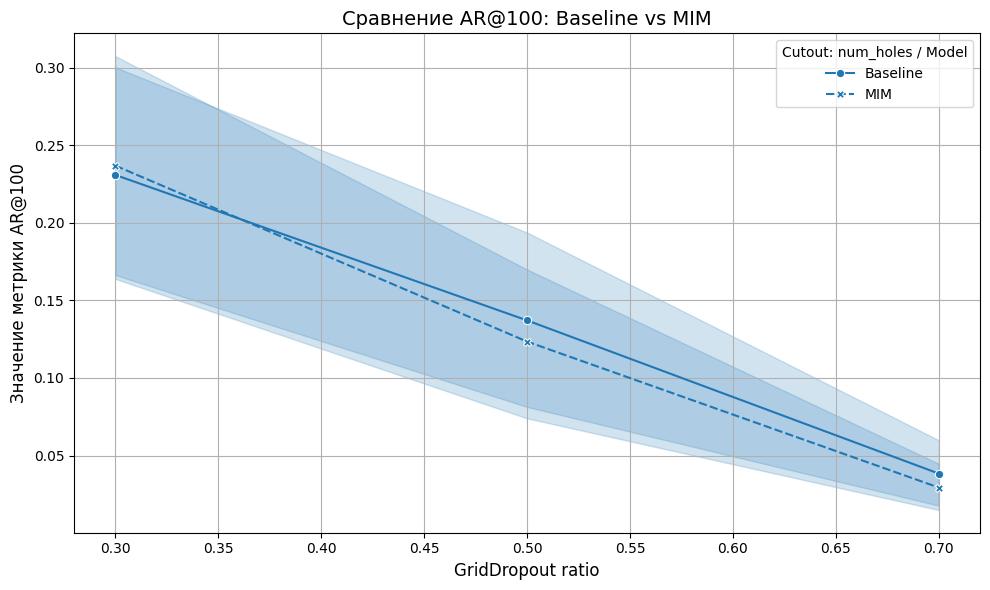

bbox_AR@300


/tmp/ipykernel_63581/3103664635.py:26: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


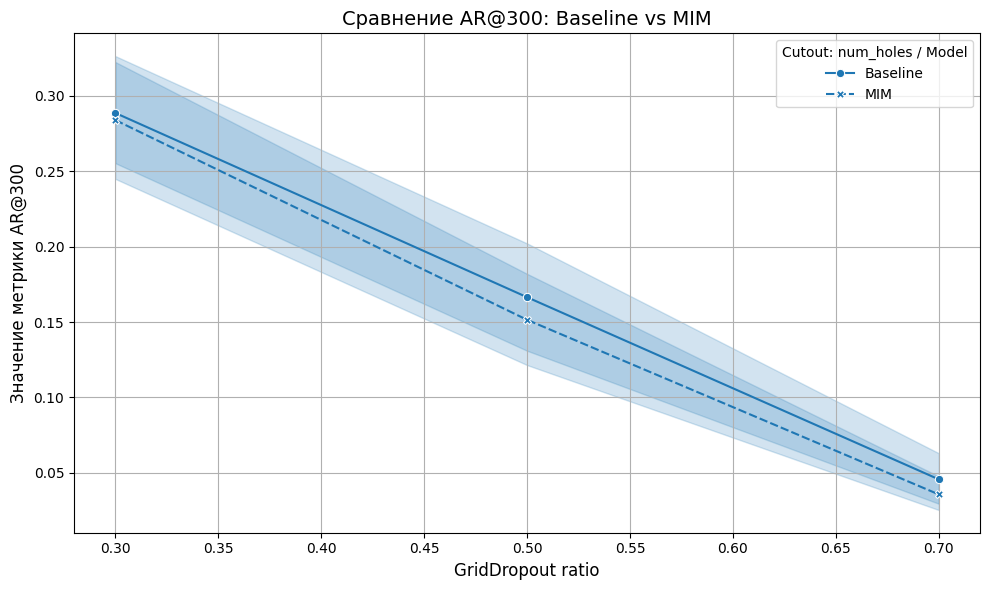

bbox_AR@1000


/tmp/ipykernel_63581/3103664635.py:26: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


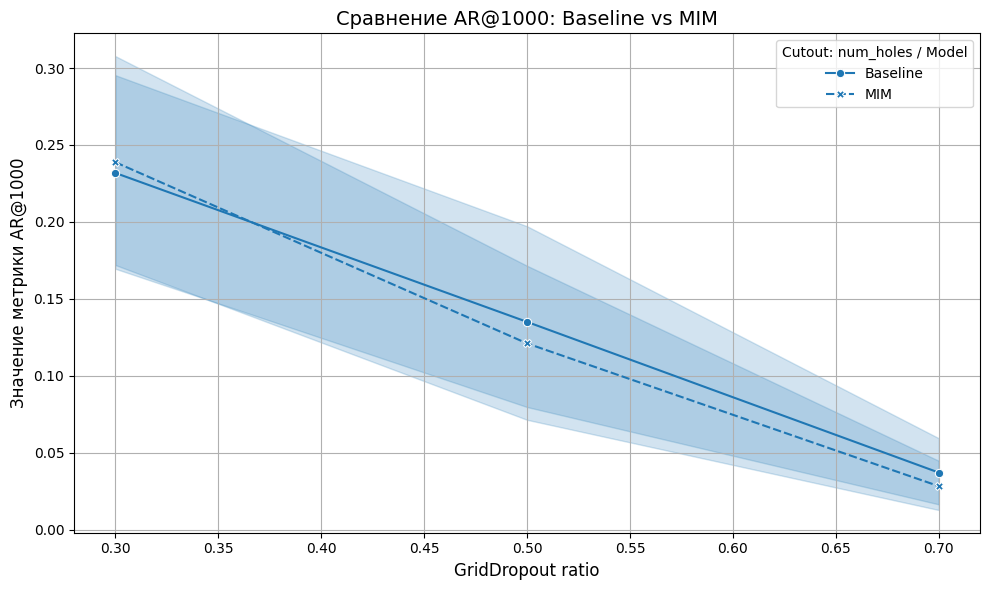

bbox_AR_s@1000


/tmp/ipykernel_63581/3103664635.py:26: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


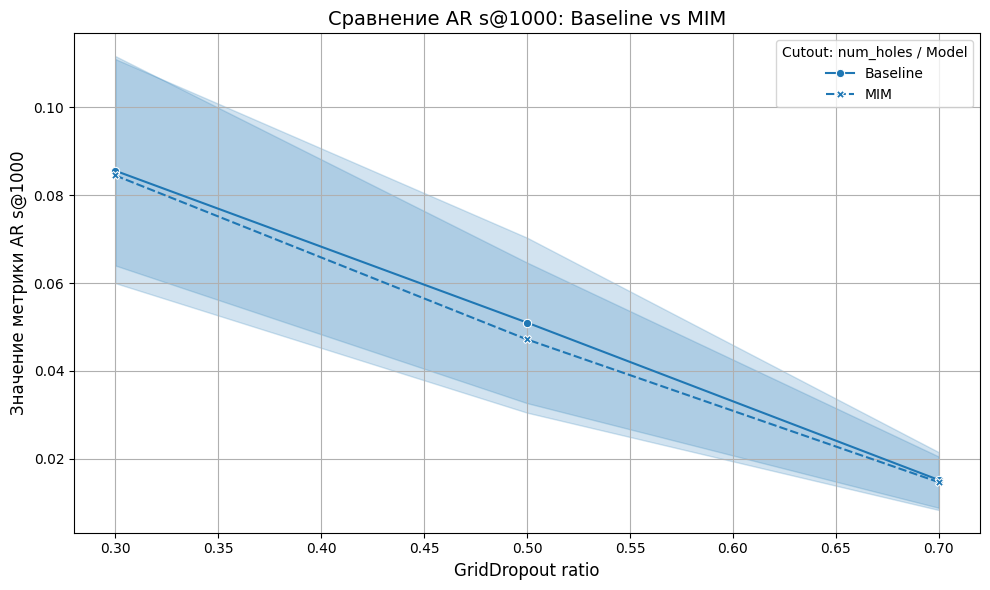

bbox_AR_m@1000


/tmp/ipykernel_63581/3103664635.py:26: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


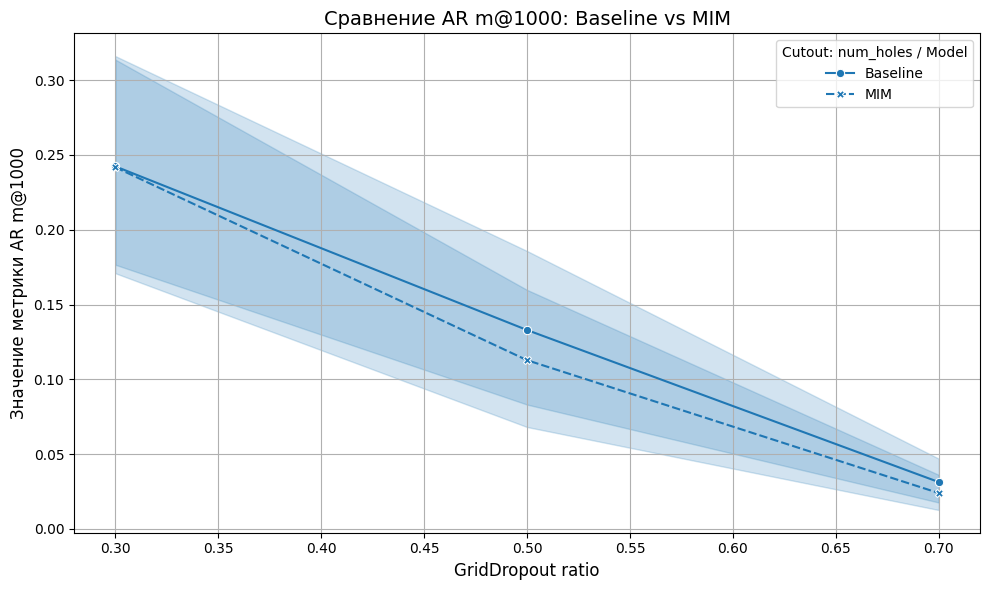

bbox_AR_l@1000


/tmp/ipykernel_63581/3103664635.py:26: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


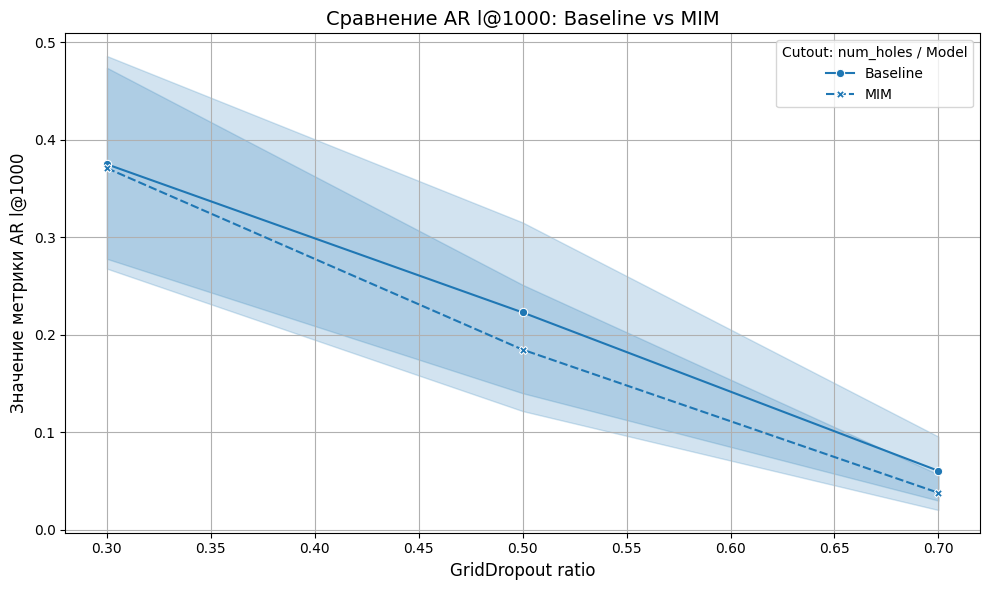

bbox_mAP


/tmp/ipykernel_63581/3103664635.py:26: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


ValueError: cannot reindex on an axis with duplicate labels

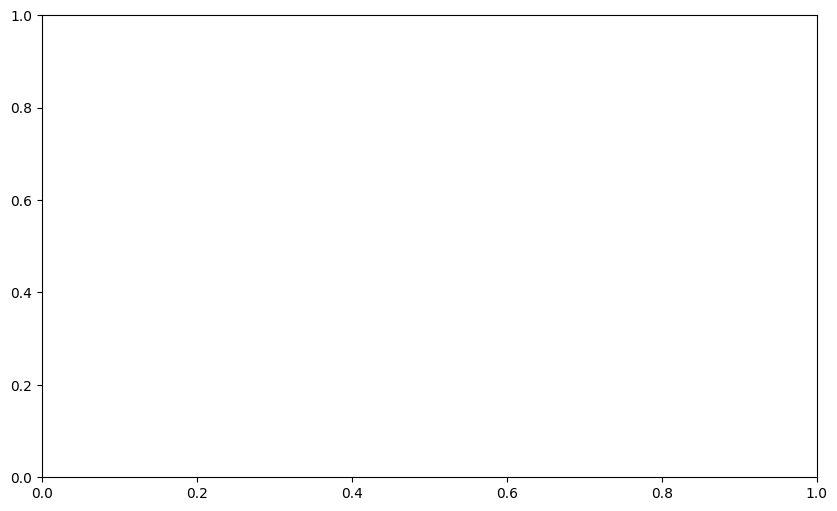

In [65]:
for i in baseline_base_data.columns:
    if 'bbox' in i:
        print(i)
        plot_comparison_mim_baseline(i, baseline_base_data, mim_base_data)
# plot_comparison_mim_baseline("bbox_mAP_75", baseline_base_data, mim_base_data )
